In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# Load one of your pass images
img = cv2.imread("data/labeled/pass/img_000061.jpg")

print("Type  :", type(img))        # numpy.ndarray
print("Shape :", img.shape)        # (height, width, 3)
print("Dtype :", img.dtype)        # uint8 — values 0 to 255
print("Min   :", img.min())
print("Max   :", img.max())
print("Pixel at [100,100]:", img[100,100])  # [Blue, Green, Red]

Type  : <class 'numpy.ndarray'>
Shape : (3024, 4032, 3)
Dtype : uint8
Min   : 0
Max   : 255
Pixel at [100,100]: [173 209 219]


Colour shape : (3024, 4032, 3)
Gray shape   : (3024, 4032)
One pixel    : 208


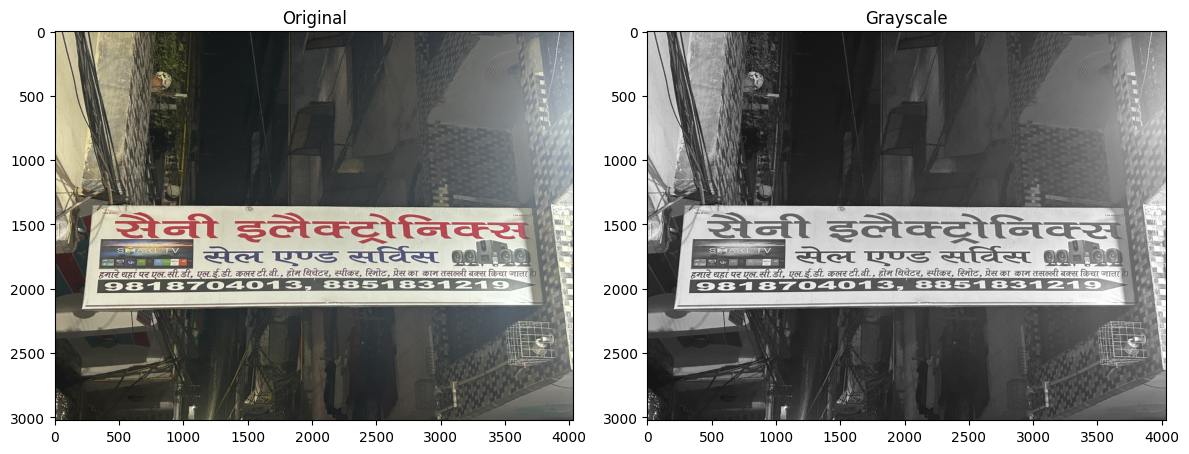

In [2]:
# Most scorers work on grayscale — one number per pixel instead of three
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Colour shape :", img.shape)    # (H, W, 3)
print("Gray shape   :", gray.shape)   # (H, W) — no channel
print("One pixel    :", gray[100,100]) # single brightness value 0-255

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax1.set_title("Original")
ax2.imshow(gray, cmap='gray'); ax2.set_title("Grayscale")
plt.tight_layout(); plt.show()

sharp    — Laplacian variance: 146.7
blurry   — Laplacian variance: 25.4


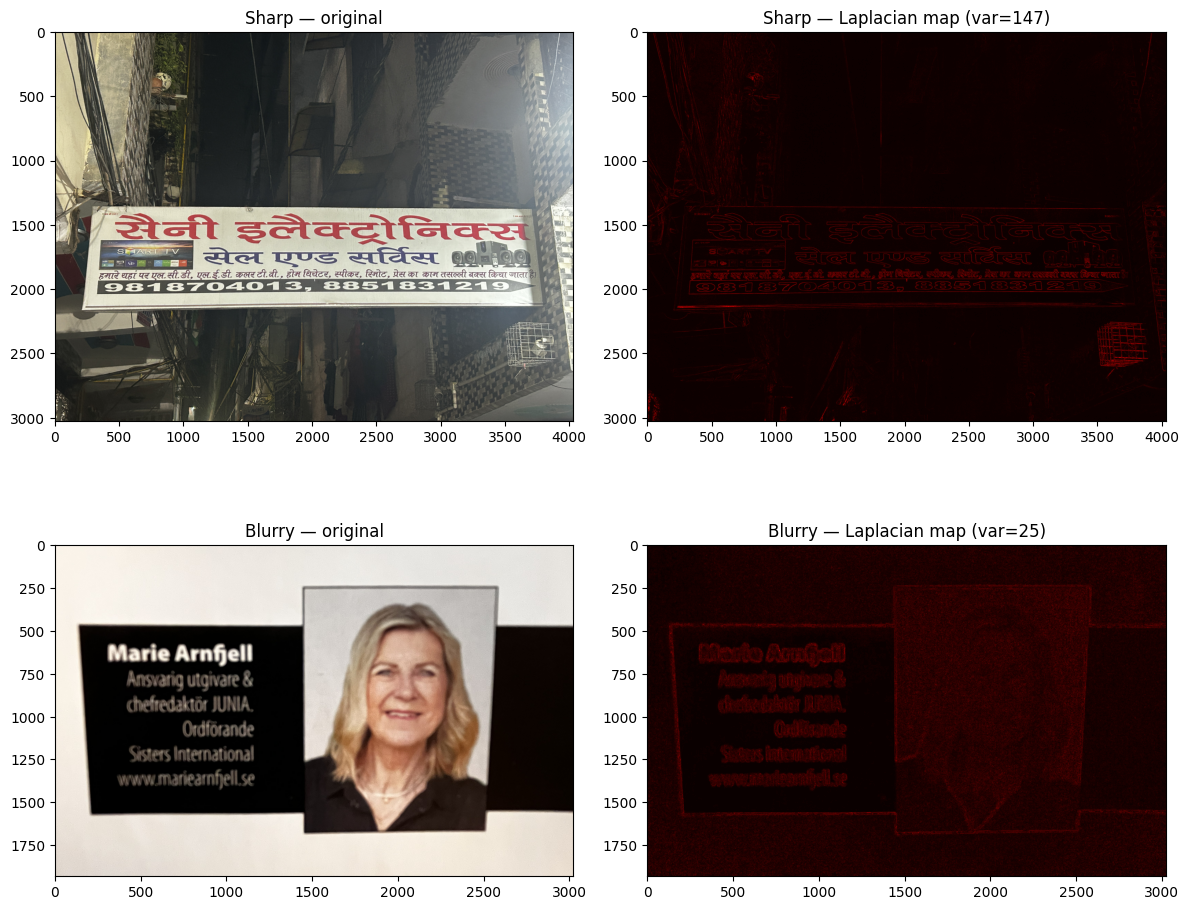

In [3]:
# Load one sharp and one blurry image
sharp  = cv2.imread("data/labeled/pass/img_000061.jpg")
blurry = cv2.imread("data/labeled/blur/img_000007.jpg")

for name, image in [("sharp", sharp), ("blurry", blurry)]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_64F)
    print(f"{name:8s} — Laplacian variance: {lap.var():.1f}")

# Visualise what the Laplacian looks like
gray_s = cv2.cvtColor(sharp,  cv2.COLOR_BGR2GRAY)
gray_b = cv2.cvtColor(blurry, cv2.COLOR_BGR2GRAY)
lap_s  = cv2.Laplacian(gray_s, cv2.CV_64F)
lap_b  = cv2.Laplacian(gray_b, cv2.CV_64F)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].imshow(cv2.cvtColor(sharp,  cv2.COLOR_BGR2RGB)); axes[0,0].set_title("Sharp — original")
axes[0,1].imshow(np.abs(lap_s), cmap='hot');               axes[0,1].set_title(f"Sharp — Laplacian map (var={lap_s.var():.0f})")
axes[1,0].imshow(cv2.cvtColor(blurry, cv2.COLOR_BGR2RGB)); axes[1,0].set_title("Blurry — original")
axes[1,1].imshow(np.abs(lap_b), cmap='hot');               axes[1,1].set_title(f"Blurry — Laplacian map (var={lap_b.var():.0f})")
plt.tight_layout(); plt.show()
# Sharp map = many bright spots (many edges)
# Blurry map = almost black (few edges)

In [4]:
def score_blur(gray: np.ndarray) -> tuple:
    """1.0 = sharp, 0.0 = blurry. Calibrated for your iPhone dataset."""
    variance = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    score    = float(np.clip(variance / 1000.0, 0.0, 1.0))
    return score, variance

# Test across all classes
import pandas as pd
rows = []
for cls in ["pass","blur","exposure","crop_error","metadata_fail"]:
    for p in list(Path(f"data/labeled/{cls}").glob("*.j*"))[:10]:
        img = cv2.imread(str(p))
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        s, v = score_blur(gray)
        rows.append({"class": cls, "blur_score": s})

df = pd.DataFrame(rows)
print(df.groupby("class")["blur_score"].mean().round(3).sort_values())
# blur class should have LOWER mean than pass class

class
blur             0.029
metadata_fail    0.326
exposure         0.368
pass             0.558
crop_error       0.999
Name: blur_score, dtype: float64


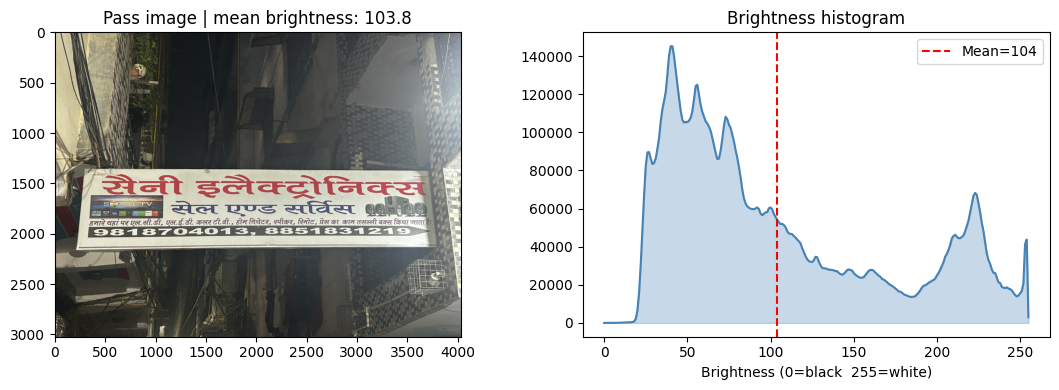

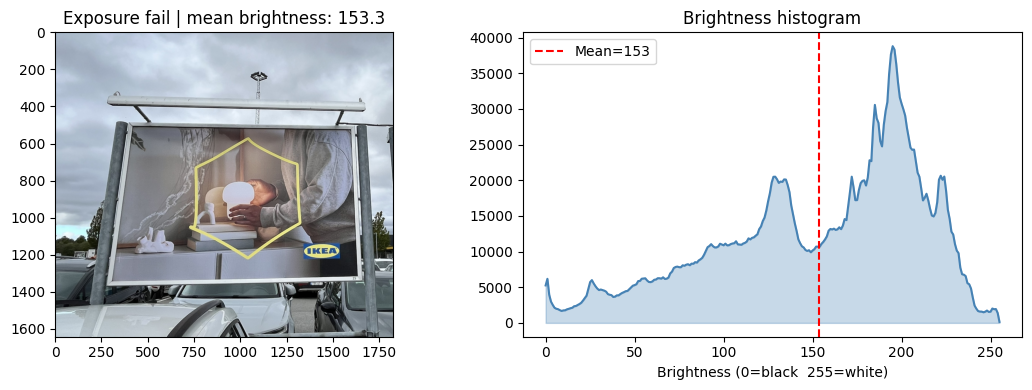

In [5]:
def show_histogram(img_path, title):
    img  = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0,256])
    mean = float(np.mean(gray))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"{title} | mean brightness: {mean:.1f}")
    ax2.plot(hist, color='steelblue')
    ax2.fill_between(range(256), hist.flatten(), alpha=0.3, color='steelblue')
    ax2.axvline(mean, color='red', linestyle='--', label=f'Mean={mean:.0f}')
    ax2.set_xlabel("Brightness (0=black  255=white)")
    ax2.legend(); ax2.set_title("Brightness histogram")
    plt.tight_layout(); plt.show()

show_histogram("data/labeled/pass/img_000061.jpg",     "Pass image")
show_histogram("data/labeled/exposure/img_000002.jpg", "Exposure fail")


In [6]:
def score_exposure(gray: np.ndarray) -> tuple:
    """1.0 = perfect exposure, 0.0 = completely dark or washed out."""
    mean = float(np.mean(gray))
    if mean < 82.0:
        score = mean / 82.0                            # underexposed
    elif mean > 142.0:
        score = 1.0 - (mean - 142.0) / (255.0 - 142.0) # overexposed
    else:
        score = 1.0 - abs(mean - 112.0) / 30.0 * 0.3  # ideal range
    return float(np.clip(score, 0.0, 1.0)), mean

# Test
rows2 = []
for cls in ["pass","blur","exposure","crop_error","metadata_fail"]:
    for p in list(Path(f"data/labeled/{cls}").glob("*.j*"))[:10]:
        img = cv2.imread(str(p))
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        s, m = score_exposure(gray)
        rows2.append({"class": cls, "exposure_score": s})

df2 = pd.DataFrame(rows2)
print(df2.groupby("class")["exposure_score"].mean().round(3).sort_values())
# exposure class should have LOWER mean than pass class

class
blur             0.815
exposure         0.821
metadata_fail    0.825
pass             0.884
crop_error       0.910
Name: exposure_score, dtype: float64


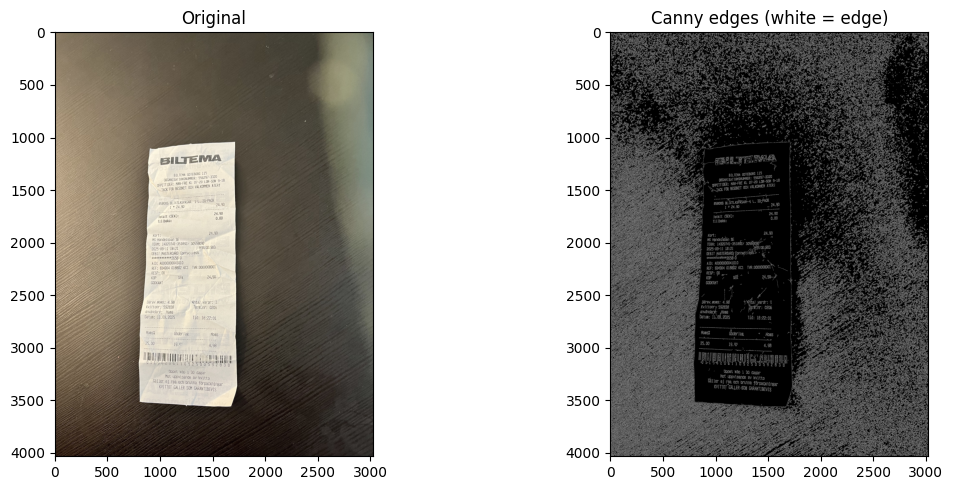

Border band: 181px wide
  top     : 0.23525
  bottom  : 0.30408
  left    : 0.30337
  right   : 0.16857


In [7]:
img_path = "data/labeled/crop_error/img_000069.jpeg"
img  = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax1.set_title("Original")
ax2.imshow(edges, cmap='gray');                   ax2.set_title("Canny edges (white = edge)")
plt.tight_layout(); plt.show()

# Check border density
h, w = gray.shape
border = int(min(h, w) * 0.06)
print(f"Border band: {border}px wide")
for name, region in [("top",edges[:border,:]),("bottom",edges[-border:,:]),
                     ("left",edges[:,:border]),("right",edges[:,-border:])]:
    density = region.sum() / (region.size * 255)
    print(f"  {name:8s}: {density:.5f}")

In [8]:
def score_crop(img: np.ndarray) -> float:
    """1.0 = clean framing, 0.0 = subject cut off at edge."""
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w   = gray.shape
    border = int(min(h, w) * 0.06)
    edges  = cv2.Canny(gray, 50, 150)
    density = np.mean([
        edges[:border,:].sum(),  edges[-border:,:].sum(),
        edges[:,:border].sum(),  edges[:,-border:].sum()
    ]) / (border * max(h,w) * 255)
    return float(np.clip(1.0 - (density / 0.1756), 0.0, 1.0))

# Test
for cls in ["pass","crop_error"]:
    for p in list(Path(f"data/labeled/{cls}").glob("*.j*"))[:5]:
        img = cv2.imread(str(p))
        if img is None: continue
        print(f"[{cls:12s}] {p.name:25s}  crop_score={score_crop(img):.3f}")
# pass should score HIGHER than crop_error

[pass        ] img_000077.jpeg            crop_score=0.091
[pass        ] img_000061.jpg             crop_score=0.848
[pass        ] img_000066.jpg             crop_score=0.902
[pass        ] img_000076.jpeg            crop_score=0.107
[pass        ] img_000084.jpeg            crop_score=0.007
[crop_error  ] img_000082.jpeg            crop_score=0.000
[crop_error  ] img_000083.jpeg            crop_score=0.000
[crop_error  ] img_000092.jpeg            crop_score=0.000
[crop_error  ] img_000088.jpeg            crop_score=0.000
[crop_error  ] img_000089.jpeg            crop_score=0.000


In [9]:
import piexif

def show_exif(path):
    print(f"\n── {Path(path).name} ──")
    try:
        exif   = piexif.load(path)
        zeroth = exif.get("0th", {})
        gps    = exif.get("GPS", {})
        print(f"  GPS       : {gps.get(piexif.GPSIFD.GPSLatitude)}")
        print(f"  Timestamp : {zeroth.get(piexif.ImageIFD.DateTime)}")
        print(f"  Camera    : {zeroth.get(piexif.ImageIFD.Make)}")
    except Exception as e:
        print(f"  No EXIF: {e}")

show_exif("data/labeled/pass/img_000061.jpg")
show_exif("data/labeled/metadata_fail/img_000000.jpg")


── img_000061.jpg ──
  GPS       : None
  Timestamp : b'2025:12:07 19:45:01'
  Camera    : b'Apple'

── img_000000.jpg ──
  GPS       : None
  Timestamp : None
  Camera    : None


In [10]:
def score_metadata(img_path: str) -> float:
    """0.0 to 1.0 — fraction of required EXIF fields present."""
    found = 0
    try:
        exif   = piexif.load(img_path)
        zeroth = exif.get("0th", {})
        gps    = exif.get("GPS", {})
        if gps.get(piexif.GPSIFD.GPSLatitude):       found += 1
        if zeroth.get(piexif.ImageIFD.DateTime):      found += 1
        if zeroth.get(piexif.ImageIFD.Make):          found += 1
    except Exception:
        found = 0
    return found / 3.0

# Test across classes
for cls in ["pass","blur","exposure","crop_error","metadata_fail"]:
    scores = [score_metadata(str(p))
              for p in list(Path(f"data/labeled/{cls}").glob("*.j*"))[:8]
              if cv2.imread(str(p)) is not None]
    if scores:
        print(f"[{cls:15s}] avg metadata score: {sum(scores)/len(scores):.2f}")

[pass           ] avg metadata score: 0.67
[blur           ] avg metadata score: 0.67
[exposure       ] avg metadata score: 0.17
[crop_error     ] avg metadata score: 0.67
[metadata_fail  ] avg metadata score: 0.00


In [12]:
import sys; sys.path.insert(0, "src")
from scorer import extract_signals
import pandas as pd

rows = []
for cls in ["pass","blur","exposure","crop_error","metadata_fail"]:
    for p in list(Path(f"data/labeled/{cls}").glob("*.j*"))[:10]:
        try:
            s = extract_signals(str(p))
            rows.append({"class":cls, "blur":round(s.blur_score,3),
                         "exposure":round(s.exposure_score,3),
                         "crop":round(s.crop_score,3),
                         "metadata":round(s.metadata_score,3)})
        except Exception as ex: print(f"Error {p.name}: {ex}")

df = pd.DataFrame(rows)
print(df.groupby("class").mean().round(3))

                blur  exposure   crop  metadata
class                                          
blur           0.029     0.815  0.948     0.600
crop_error     0.999     0.910  0.000     0.667
exposure       0.368     0.821  0.825     0.133
metadata_fail  0.326     0.825  0.769     0.000
pass           0.559     0.884  0.486     0.667
